# v2 Data Prep — OAG-CS with Hard Negatives

## What's new vs `02b_prepare_oag_cs.ipynb` (v1)

1. **Loads field-of-study (FoS) edges** at every available level (`PF_in_L0`, `PF_in_L1`, ...). v1 ignored fields entirely.
2. **Diagnostic cell** — for every FoS level, prints mean / median / max papers per field, so you can choose `FOS_LEVEL` informedly.
3. **Tunable `FOS_LEVEL`** — chosen level defines the hard-negative pool. Default `2` (specific enough to be a meaningful hard signal, not so specific that pools become tiny).
4. **Hard-negative sampling (A1 strict)** — a paper `q` is a hard negative for predicting positive `p` if it shares ≥1 field at `FOS_LEVEL` with `p`.
5. **Eval candidate composition (B1)** — val and small-test sets contain ~50% hard + ~50% random negatives, totaling ~1000 candidates.
6. **Tunable training negatives (C2)** — every training example stores both `negatives_random` and `negatives_hard`. Training notebook picks `random` / `hard` / `mixed` at run time.
7. **Full-pool test (T1)** — test examples additionally save `known_locals`, so the training notebook can rank against all ~546K papers (excluding self/known/positives) for the headline number.
8. **Output dir** — `./data/processed_v2/` (v1 untouched).

Author embedding strategy is unchanged at the prep layer — author representations are mean-pooled paper embeddings everywhere downstream (the v1 GAT eval already does this; we are now committing to it as the only strategy).

## Step 1 — Imports and seeds

Pulls in PyTorch / PyG / NumPy and pins random seeds so any future re-run produces identical splits and identical hard-negative samples.

In [2]:
import re
import time
import random
from pathlib import Path
from collections import defaultdict

import torch
import numpy as np
import matplotlib.pyplot as plt

from torch_geometric.data import Data, HeteroData
from H2GB.datasets import OAGDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Step 2 — Configuration

All tunable knobs in one place, so the rest of the notebook reads as a deterministic pipeline.

Why each parameter:

- `VAL_YEAR=2017`, `TEST_YEAR=2018`, `TRAIN_YEAR_START=2005` — temporal split. Papers ≥ 2018 are test, year 2017 is val, 2005–2016 is training supervision (graph at year `y` uses papers `<y`, preventing leakage).
- `NEG_SAMPLES=5` — training negatives per positive citation. Standard recsys default.
- `EVAL_TOTAL_CANDIDATES=1000` — small-eval candidate set size (positives + ~999 negatives) for fast per-epoch validation.
- `EVAL_HARD_FRAC=0.5` — half the eval negatives are hard (same-field), half are random. Lets us inspect both regimes on one combined Hits@10.
- `FOS_LEVEL=2` — FoS hierarchy level for the hard-negative pool. Inspect Step 4's diagnostic before changing.
- `MIN_AUTHOR_PAPERS=2` — drop authors with a single paper (62% of authors per CLAUDE.md notes); they have no usable history.
- `BUILD_FULL_POOL_TEST=True` — at test time, also save `known_locals` so the training notebook can rank against all papers.

In [3]:
# --- Paths ---
OAG_ROOT = Path("./data/OAG")               # dataset cache (read-only here)
PROCESSED_DIR = Path("./data/processed_v2") # v2 output dir — keeps v1 intact
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# --- Temporal split ---
VAL_YEAR = 2017
TEST_YEAR = 2018
TRAIN_YEAR_START = 2005
MIN_AUTHOR_PAPERS = 2

# --- Negative sampling ---
NEG_SAMPLES = 5                  # per-positive training negatives (each kind: random and hard)
EVAL_TOTAL_CANDIDATES = 1000     # candidate set size for val + small-test eval
EVAL_HARD_FRAC = 0.5             # fraction of eval negatives that are hard (rest random)

# --- FoS level (REVIEW Step 4 STATS BEFORE CHANGING) ---
FOS_LEVEL = 2                    # which PF_in_L{level} to use for hard-neg matching

# --- Test-time options ---
BUILD_FULL_POOL_TEST = True      # save known_locals for full-pool ranking at test

print(f"Output dir: {PROCESSED_DIR}")
print(f"Train sup years: {TRAIN_YEAR_START}..{VAL_YEAR-1}, val={VAL_YEAR}, test={TEST_YEAR}")
print(f"Neg sampling: NEG_SAMPLES={NEG_SAMPLES}, eval={EVAL_TOTAL_CANDIDATES} (hard frac={EVAL_HARD_FRAC})")
print(f"FOS_LEVEL={FOS_LEVEL} (review Step 4 stats first!)")

Output dir: data/processed_v2
Train sup years: 2005..2016, val=2017, test=2018
Neg sampling: NEG_SAMPLES=5, eval=1000 (hard frac=0.5)
FOS_LEVEL=2 (review Step 4 stats first!)


## Step 3 — Load OAG-CS

Same loading recipe as v1 / data_analysis: H2GB's `OAGDataset` with the URL bypassed because the dataset is pre-staged on the cluster. We then pull out paper features, citation edges, and authorship edges from the resulting `HeteroData`.

In [4]:
OAGDataset.names['oag-cs'] = 'cs'
OAGDataset.urls['oag-cs'] = 'bypassed'

class CS_OAGDataset(OAGDataset):
    def __init__(self, root, transform=None, pre_transform=None):
        self.name = 'oag-cs'
        super(OAGDataset, self).__init__(root, transform, pre_transform)
        self.data, self.slices = torch.load(self.processed_paths[0], weights_only=False)
    def download(self):
        pass

dataset = CS_OAGDataset(root=str(OAG_ROOT))
data = dataset[0]

print(f"Node types: {data.node_types}")
print(f"Edge types: {data.edge_types}")

Node types: ['paper', 'field', 'author', 'affiliation']
Edge types: [('paper', 'PP_cite', 'paper'), ('author', 'AP_write_last', 'paper'), ('author', 'AP_write_other', 'paper'), ('author', 'AP_write_first', 'paper'), ('field', 'FF_in', 'field'), ('paper', 'PF_in_L0', 'field'), ('paper', 'PF_in_L3', 'field'), ('paper', 'PF_in_L1', 'field'), ('paper', 'PF_in_L2', 'field'), ('paper', 'PF_in_L5', 'field'), ('paper', 'PF_in_L4', 'field'), ('author', 'in', 'affiliation')]


## Step 4 — Extract paper features, citation edges, authorship edges

Paper features: `(num_papers, 768)` SciBERT-style title embeddings. Years: `(num_papers,)` ints. Citations: `(2, num_cite)` directed edges (`src` cites `dst`). Authorship: merged across the three relations `AP_write_first/last/other` and de-duplicated.

In [5]:
# --- Paper data ---
embeddings = data['paper'].x                 # (N_papers, 768)
years = data['paper'].year                   # (N_papers,)
num_papers = embeddings.shape[0]
embed_dim = embeddings.shape[1]
print(f"Papers: {num_papers:,}  embed_dim: {embed_dim}  year range: {years.min().item()}..{years.max().item()}")

# --- Citation edges ---
cite_edge_index = data['paper', 'PP_cite', 'paper'].edge_index
cite_src, cite_dst = cite_edge_index[0], cite_edge_index[1]
print(f"Citation edges: {cite_src.shape[0]:,}")

# --- Authorship edges (merge first/last/other, drop dup pairs) ---
auth_a, auth_p = [], []
for rel in ['AP_write_first', 'AP_write_last', 'AP_write_other']:
    ei = data['author', rel, 'paper'].edge_index
    auth_a.append(ei[0]); auth_p.append(ei[1])
    print(f"  {rel}: {ei.shape[1]:,}")
auth_a = torch.cat(auth_a); auth_p = torch.cat(auth_p)
pairs = torch.stack([auth_a, auth_p], dim=1)
pairs = torch.unique(pairs, dim=0)
author_paper_author = pairs[:, 0]
author_paper_paper  = pairs[:, 1]
num_authors = data['author'].num_nodes
print(f"Unique author–paper links: {len(author_paper_author):,}  authors: {num_authors:,}")

Papers: 546,704  embed_dim: 768  year range: 1922..2020
Citation edges: 5,872,552
  AP_write_first: 456,903
  AP_write_last: 431,027
  AP_write_other: 664,266
Unique author–paper links: 1,552,196  authors: 511,122


## Step 5 — Discover paper→field edges across all hierarchy levels

OAG-CS provides multiple FoS levels via `('paper', 'PF_in_L{level}', 'field')` edge types. L0 is the broadest (e.g. "Computer Science"), and granularity increases with level. We auto-detect every available level so the notebook works regardless of how many levels OAG-CS exposes.

In [6]:
fos_edge_types = []
for et in data.edge_types:
    src, rel, dst = et
    if src == 'paper' and dst == 'field' and 'PF_in_L' in rel:
        m = re.search(r'L(\d+)', rel)
        if m:
            fos_edge_types.append((int(m.group(1)), et))
fos_edge_types.sort()
available_levels = [lvl for lvl, _ in fos_edge_types]
print(f"Available FoS levels: {available_levels}")
for lvl, et in fos_edge_types:
    print(f"  L{lvl}: edge type {et}, edges={data[et].edge_index.shape[1]:,}")

Available FoS levels: [0, 1, 2, 3, 4, 5]
  L0: edge type ('paper', 'PF_in_L0', 'field'), edges=546,831
  L1: edge type ('paper', 'PF_in_L1', 'field'), edges=1,202,487
  L2: edge type ('paper', 'PF_in_L2', 'field'), edges=2,347,239
  L3: edge type ('paper', 'PF_in_L3', 'field'), edges=869,729
  L4: edge type ('paper', 'PF_in_L4', 'field'), edges=304,912
  L5: edge type ('paper', 'PF_in_L5', 'field'), edges=203,338


## Step 6 — Per-level FoS statistics (the diagnostic)

**Use this table to choose `FOS_LEVEL`.** For each level it shows:

- `n_fields` — number of distinct fields at that level. Larger = finer granularity.
- `mean_papers_per_field` — average pool size for hard negatives if this level were used. Want this large enough that sampling 500 hard negs is feasible (≫500), but small enough that papers in the same field are actually topically similar (not all of CS).
- `median / max papers/field` — how skewed the distribution is. A few mega-fields can dominate at coarse levels.
- `mean_fields_per_paper` — how many fields each paper carries; affects hard-pool sizes for multi-field positives.

Heuristic: pick the largest level where `mean_papers_per_field` ≥ a few thousand. L0/L1 are usually too broad (mean in the 100K range — every paper a hard neg). L2/L3 typically give the right granularity.

After running this cell, return to Step 2 and edit `FOS_LEVEL` if needed, then re-run from Step 7 onward.

 L |  n_fields | paper_cov |    mean_p/f |   med_p/f |   max_p/f |  mean_f/p
----------------------------------------------------------------------------
 0 |        13 |    100.0% |    42,063.9 |      11.0 |   546,704 |      1.00
 1 |       275 |    100.0% |     4,372.7 |      47.0 |   172,108 |      2.20
 2 |    17,750 |     96.9% |       132.2 |       6.0 |    27,634 |      4.43
 3 |    14,615 |     78.6% |        59.5 |       4.0 |    10,518 |      2.02
 4 |     7,245 |     37.2% |        42.1 |       4.0 |     2,740 |      1.50
 5 |     5,877 |     21.0% |        34.6 |       5.0 |     1,829 |      1.77


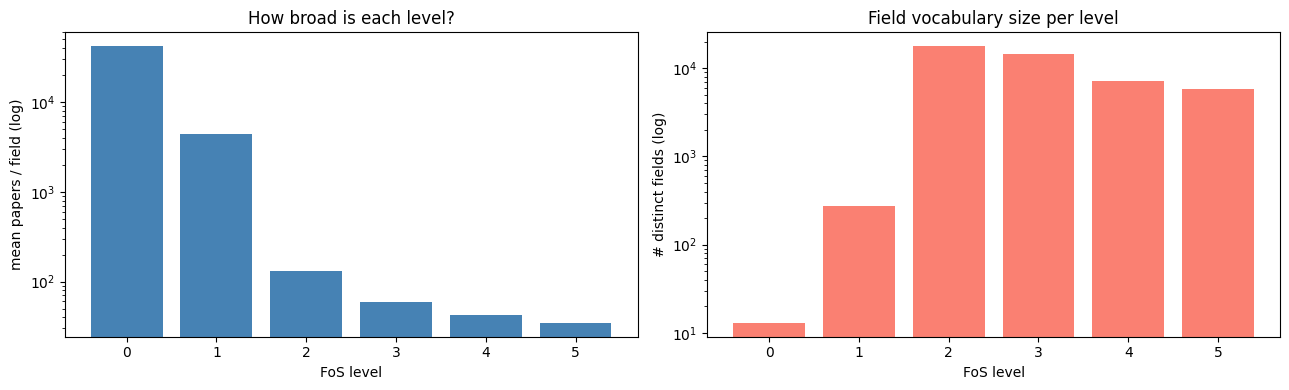


Using FOS_LEVEL = 2 for hard-negative pools.


In [7]:
level_stats = []
for lvl, et in fos_edge_types:
    ei = data[et].edge_index
    paper_ids, field_ids = ei[0], ei[1]
    n_edges = ei.shape[1]
    # papers per field
    _, ppf = torch.unique(field_ids, return_counts=True)
    n_fields = ppf.numel()
    # fields per paper
    _, fpp = torch.unique(paper_ids, return_counts=True)
    coverage = fpp.numel() / num_papers
    level_stats.append({
        'level': lvl,
        'n_edges': n_edges,
        'n_fields': n_fields,
        'paper_coverage': coverage,
        'mean_papers_per_field': ppf.float().mean().item(),
        'median_papers_per_field': ppf.float().median().item(),
        'max_papers_per_field': ppf.max().item(),
        'min_papers_per_field': ppf.min().item(),
        'mean_fields_per_paper': fpp.float().mean().item(),
        'median_fields_per_paper': fpp.float().median().item(),
        'max_fields_per_paper': fpp.max().item(),
    })

# Pretty print
header = f"{'L':>2} | {'n_fields':>9} | {'paper_cov':>9} | {'mean_p/f':>11} | {'med_p/f':>9} | {'max_p/f':>9} | {'mean_f/p':>9}"
print(header)
print('-' * len(header))
for s in level_stats:
    print(f"{s['level']:>2} | {s['n_fields']:>9,} | {s['paper_coverage']*100:>8.1f}% | "
          f"{s['mean_papers_per_field']:>11,.1f} | {s['median_papers_per_field']:>9,.1f} | "
          f"{s['max_papers_per_field']:>9,} | {s['mean_fields_per_paper']:>9.2f}")

# Plot the two key numbers per level
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
lv = [s['level'] for s in level_stats]
axes[0].bar(lv, [s['mean_papers_per_field'] for s in level_stats], color='steelblue')
axes[0].set_yscale('log'); axes[0].set_xlabel('FoS level'); axes[0].set_ylabel('mean papers / field (log)')
axes[0].set_title('How broad is each level?')
axes[1].bar(lv, [s['n_fields'] for s in level_stats], color='salmon')
axes[1].set_yscale('log'); axes[1].set_xlabel('FoS level'); axes[1].set_ylabel('# distinct fields (log)')
axes[1].set_title('Field vocabulary size per level')
plt.tight_layout(); plt.savefig(str(PROCESSED_DIR / 'fos_level_stats.png'), dpi=150); plt.show()

if FOS_LEVEL not in available_levels:
    raise ValueError(f"FOS_LEVEL={FOS_LEVEL} is not in available levels {available_levels}.")
print(f"\nUsing FOS_LEVEL = {FOS_LEVEL} for hard-negative pools.")

## Step 7 — Build paper↔field lookups for the chosen level

Two dicts keyed by **global** paper IDs (we'll convert to local IDs during supervision build per-year):

- `paper_to_fields[p] = list[field_id]` — for sampling hard negatives, we need to know what fields each positive paper belongs to.
- `field_to_papers[f] = set[paper_id]` — for sampling: union over a paper's fields gives its hard-negative pool. Sets allow O(1) membership and fast set-ops downstream.

Built once globally; downstream code restricts to per-year local IDs as needed.

In [8]:
fos_et = dict(fos_edge_types)[FOS_LEVEL]
ei = data[fos_et].edge_index
fos_paper_ids = ei[0].tolist()
fos_field_ids = ei[1].tolist()

paper_to_fields_global = defaultdict(list)   # paper_id -> [field_id, ...]
field_to_papers_global = defaultdict(set)    # field_id -> {paper_id, ...}
for p, f in zip(fos_paper_ids, fos_field_ids):
    paper_to_fields_global[p].append(f)
    field_to_papers_global[f].add(p)

papers_with_field = len(paper_to_fields_global)
n_fields_used = len(field_to_papers_global)
print(f"FOS_LEVEL={FOS_LEVEL}: {papers_with_field:,} papers tagged "
      f"({100*papers_with_field/num_papers:.1f}% coverage), {n_fields_used:,} distinct fields")

# Sample sanity check: pool size for a random tagged paper
_p_sample = next(iter(paper_to_fields_global))
_pool = set()
for f in paper_to_fields_global[_p_sample]:
    _pool |= field_to_papers_global[f]
print(f"Sanity: paper {_p_sample} has {len(paper_to_fields_global[_p_sample])} fields "
      f"and a same-field pool of {len(_pool):,} papers (incl. itself).")

FOS_LEVEL=2: 529,808 papers tagged (96.9% coverage), 17,750 distinct fields
Sanity: paper 134598 has 3 fields and a same-field pool of 7,478 papers (incl. itself).


## Step 8 — Build author / paper / citation lookup tables

Three dicts used everywhere downstream. Identical to v1.
- `author_to_papers[a] = [(paper_id, year), ...]` — drives history construction and the "known papers" filter.
- `paper_to_citations[p] = [cited_paper_id, ...]` — supervises positives at the supervision year, and contributes to known-papers expansion.
- `paper_to_authors[p] = [author_id, ...]` — used to enumerate authors of supervision-year papers.

In [9]:
print("Building lookups...")
author_to_papers = defaultdict(list)
for i in range(len(author_paper_author)):
    a = author_paper_author[i].item()
    p = author_paper_paper[i].item()
    y = years[p].item()
    author_to_papers[a].append((p, y))

paper_to_citations = defaultdict(list)
for i in range(len(cite_src)):
    paper_to_citations[cite_src[i].item()].append(cite_dst[i].item())

paper_to_authors = defaultdict(list)
for i in range(len(author_paper_author)):
    paper_to_authors[author_paper_paper[i].item()].append(author_paper_author[i].item())

print(f"  authors w/ ≥1 paper: {len(author_to_papers):,}")
print(f"  papers w/ outgoing citations: {len(paper_to_citations):,}")
print(f"  papers w/ ≥1 author: {len(paper_to_authors):,}")

Building lookups...
  authors w/ ≥1 paper: 511,122
  papers w/ outgoing citations: 512,753
  papers w/ ≥1 author: 481,366


## Step 9 — Graph builders

Each supervision year `y` produces two graph variants, both built over **only papers strictly before `y`** (preventing temporal leakage).

- **`build_homo_graph`** — single undirected paper–paper relation: cites + cited-by collapsed into one edge type. Baseline used by GraphSAGE/homogeneous GAT.
- **`build_hetero_graph`** — paper-only graph with **two separate directed edge types**: `('paper','cites','paper')` and `('paper','cited_by','paper')`. **No author nodes** (dropped from v1 — author representations are now mean-pooled paper embeddings everywhere downstream). This variant lets a relation-aware GNN attend differently to outgoing vs incoming citations, directly testing CLAUDE.md research question 1 (\"does heterogeneous attention beat simple graph propagation?\").

In [10]:
def build_homo_graph(years, embeddings, cite_src, cite_dst, before_year):
    """Single undirected edge type — cites + cited-by collapsed into one relation."""
    paper_mask = years < before_year
    l2g = paper_mask.nonzero(as_tuple=True)[0]
    n = len(l2g)
    g2l = {l2g[i].item(): i for i in range(n)}
    x = embeddings[l2g]
    src, dst = [], []
    for i in range(len(cite_src)):
        s, d = cite_src[i].item(), cite_dst[i].item()
        if s in g2l and d in g2l:
            sl, dl = g2l[s], g2l[d]
            src.extend([sl, dl]); dst.extend([dl, sl])  # undirected
    g = Data(x=x, edge_index=torch.tensor([src, dst], dtype=torch.long))
    g.num_nodes = n
    return g, g2l, l2g

def build_hetero_graph(years, embeddings, cite_src, cite_dst, before_year):
    """Paper-only graph with two separate directed edge types: `cites` and `cited_by`.

    Author nodes are intentionally omitted — author reps are mean-pooled paper embeddings
    downstream, so adding author nodes would only increase memory without changing the
    eval signal. The two-relation structure is what we test in v2.
    """
    paper_mask = years < before_year
    p_l2g = paper_mask.nonzero(as_tuple=True)[0]
    n_p = len(p_l2g)
    p_g2l = {p_l2g[i].item(): i for i in range(n_p)}
    cs, cd, bs, bd = [], [], [], []
    for i in range(len(cite_src)):
        s, d = cite_src[i].item(), cite_dst[i].item()
        if s in p_g2l and d in p_g2l:
            cs.append(p_g2l[s]); cd.append(p_g2l[d])    # cites: src cites dst
            bs.append(p_g2l[d]); bd.append(p_g2l[s])    # cited_by: dst is cited by src
    g = HeteroData()
    g['paper'].x = embeddings[p_l2g]
    g['paper'].num_nodes = n_p
    g['paper', 'cites', 'paper'].edge_index = torch.tensor([cs, cd], dtype=torch.long)
    g['paper', 'cited_by', 'paper'].edge_index = torch.tensor([bs, bd], dtype=torch.long)
    return g, p_g2l, p_l2g

## Step 10 — Author histories and known-papers helpers

- `build_author_histories(...)` — for each eligible author with ≥`MIN_AUTHOR_PAPERS` total papers, collect the *local* IDs of their pre-`before_year` papers. This list becomes the input to mean-pooling at training and eval (history-only profile).
- `build_known_papers(...)` — papers an author already "knows" in their pre-supervision life: own papers + papers cited by their own pre-year papers. Excluded from eval candidate pools so we measure recommendation of *new* knowledge, not retrieval of stuff the author already cited.

In [11]:
def build_author_histories(author_to_papers, global_to_local, before_year, min_papers=2):
    histories = {}
    for a, plist in author_to_papers.items():
        if len(plist) < min_papers:
            continue
        local_ids = [global_to_local[p] for p, py in plist
                     if py < before_year and p in global_to_local]
        if local_ids:
            histories[a] = local_ids
    return histories

def build_known_papers(author_id, author_to_papers, paper_to_citations, before_year):
    known = set()
    for p, py in author_to_papers[author_id]:
        known.add(p)
        if py < before_year and p in paper_to_citations:
            known.update(paper_to_citations[p])
    return known

## Step 11 — Hard / random negative sampling

Core new logic. Given a list of positive *local* paper IDs and the per-year local field lookups, return `(random_negs, hard_negs)`.

Hard pool definition (A1, strict): the union over all positives of "papers sharing ≥1 field at FOS_LEVEL with that positive". We exclude positives themselves and any externally-supplied `exclude` set (e.g. known papers at eval time).

Implementation notes:
- We pre-build per-year **local** `paper_to_fields_local` and `field_to_papers_local` (maps from global to local IDs once per year), so sampling stays in the local index space the rest of the pipeline uses.
- Random sampling uses **rejection sampling** against `forbidden = positives ∪ exclude ∪ already_chosen`. With forbidden sets of a few thousand IDs and pools of ~100K+ papers, rejection rate is tiny — far faster than building set-differences over full pools per author.
- If the hard pool is too small to fill `num_hard`, we top up with random negatives. The function reports the actual counts via the returned lists' lengths.

In [12]:
def localize_fos(global_to_local, paper_to_fields_global, field_to_papers_global):
    """Map global FoS lookups to local IDs for the current year's graph.
    Only papers present in `global_to_local` survive.
    """
    p2f_local = {}
    f2p_local = defaultdict(set)
    for p_global, fields in paper_to_fields_global.items():
        if p_global not in global_to_local:
            continue
        p_local = global_to_local[p_global]
        p2f_local[p_local] = fields  # field IDs are global, but we use them only as keys
        for f in fields:
            f2p_local[f].add(p_local)
    return p2f_local, f2p_local

def sample_negatives(positive_locals, p2f_local, f2p_local,
                     all_local_arr, num_random, num_hard, exclude=None):
    """Return (random_negs, hard_negs) as lists of local IDs.

    `all_local_arr` is a numpy int array of every local paper ID in the current year's graph,
    used as the random-sampling universe.
    `exclude` is an optional iterable of local IDs to forbid (e.g., known papers at eval).
    """
    pos_set = set(positive_locals)
    forbidden = set(pos_set)
    if exclude:
        forbidden |= set(exclude)

    # Hard pool: union over positives of same-field papers (local IDs)
    hard_pool = set()
    for p in positive_locals:
        for f in p2f_local.get(p, ()):
            hard_pool |= f2p_local.get(f, set())
    hard_pool -= forbidden

    # Sample hard
    if num_hard > 0 and hard_pool:
        pool_list = list(hard_pool)
        k = min(num_hard, len(pool_list))
        idx = np.random.choice(len(pool_list), size=k, replace=False)
        hard_negs = [pool_list[i] for i in idx]
    else:
        hard_negs = []
    shortage = num_hard - len(hard_negs)

    # Sample random via rejection — forbid positives + exclude + already-chosen hard + already-chosen random
    target_random = num_random + shortage
    rand_forbidden = forbidden | set(hard_negs)
    chosen_rand = []
    chosen_set = set()
    n_universe = len(all_local_arr)
    if target_random > 0 and n_universe > 0:
        attempts = 0
        max_attempts = 50
        while len(chosen_rand) < target_random and attempts < max_attempts:
            n_to_try = min(n_universe, max(target_random * 2, 64))
            cand = np.random.choice(all_local_arr, size=n_to_try, replace=False)
            for c in cand:
                ci = int(c)
                if ci in rand_forbidden or ci in chosen_set:
                    continue
                chosen_rand.append(ci); chosen_set.add(ci)
                if len(chosen_rand) >= target_random:
                    break
            attempts += 1
    return chosen_rand, hard_negs

## Step 12 — Supervision builder (v2)

For each supervision year, iterate over papers from that year. For each paper's authors (with eligible history), construct one supervision example:

**Training (`is_eval=False`):**
- Positives: papers cited by the supervision-year paper (after mapping to local IDs of the pre-year graph).
- Sample `NEG_SAMPLES * |positives|` random negatives **and** the same number of hard negatives.
- We store *both* lists; the training notebook can pick `random` / `hard` / `mixed` at run time without re-running prep.

**Eval (`is_eval=True`):**
- Positives: same, but additionally filtered to those NOT in the author's known-papers set.
- Negatives: a single mixed list of `EVAL_TOTAL_CANDIDATES - |filtered_positives|` items, ~half hard / half random (per `EVAL_HARD_FRAC`).
- Excluded from negative pools: positives, known papers.
- For test additionally save `known_locals` so the training notebook can rank the model output against the **full ~546K paper pool** (T1) by masking positives + known and ranking the remainder. This gives the headline "all-papers Hits@10" number.

Each example dict carries enough info for any downstream eval mode without re-touching the dataset.

In [13]:
def build_supervision_v2(author_to_papers, paper_to_citations, paper_to_authors,
                         years, global_to_local,
                         author_histories,
                         p2f_local, f2p_local,
                         supervision_year, neg_samples,
                         is_eval=False,
                         eval_total_candidates=1000,
                         eval_hard_frac=0.5,
                         save_known_locals=False):
    all_local_arr = np.fromiter(global_to_local.values(), dtype=np.int64)
    sup_papers = (years == supervision_year).nonzero(as_tuple=True)[0].tolist()
    examples = []
    seen_authors = set()

    for paper_global in sup_papers:
        if paper_global not in paper_to_citations:
            continue
        cited_locals = [global_to_local[c] for c in paper_to_citations[paper_global]
                        if c in global_to_local]
        if not cited_locals:
            continue
        if paper_global not in paper_to_authors:
            continue
        for a in paper_to_authors[paper_global]:
            if a in seen_authors or a not in author_histories:
                continue
            seen_authors.add(a)
            history_locals = author_histories[a]
            positive_set = set(cited_locals)

            if is_eval:
                known_globals = build_known_papers(a, author_to_papers, paper_to_citations,
                                                   supervision_year)
                known_locals = {global_to_local[g] for g in known_globals if g in global_to_local}
                filtered_pos = [p for p in cited_locals if p not in known_locals]
                if not filtered_pos:
                    continue
                # Eval candidate set: `eval_total_candidates` — positives + (rest mixed hard/random)
                num_negs_total = max(0, eval_total_candidates - len(filtered_pos))
                num_hard = int(round(num_negs_total * eval_hard_frac))
                num_rand = num_negs_total - num_hard
                rand_negs, hard_negs = sample_negatives(
                    filtered_pos, p2f_local, f2p_local, all_local_arr,
                    num_random=num_rand, num_hard=num_hard,
                    exclude=known_locals,
                )
                ex = {
                    'author_id': a,
                    'positive_locals': filtered_pos,
                    'negative_locals_mixed': rand_negs + hard_negs,
                    'num_hard_negatives': len(hard_negs),
                    'num_random_negatives': len(rand_negs),
                    'history_locals': history_locals,
                }
                if save_known_locals:
                    ex['known_locals'] = list(known_locals)
                examples.append(ex)
            else:
                # Training: per-author symmetric counts so the training notebook can pick strategy
                k = neg_samples * len(cited_locals)
                rand_negs, _ = sample_negatives(
                    cited_locals, p2f_local, f2p_local, all_local_arr,
                    num_random=k, num_hard=0,
                )
                _, hard_negs = sample_negatives(
                    cited_locals, p2f_local, f2p_local, all_local_arr,
                    num_random=0, num_hard=k,
                )
                examples.append({
                    'author_id': a,
                    'positive_locals': cited_locals,
                    'negatives_random': rand_negs,
                    'negatives_hard': hard_negs,
                    'history_locals': history_locals,
                })
    return examples

## Step 13 — Build per-year training data

For every year `y ∈ [TRAIN_YEAR_START, VAL_YEAR-1]`:
1. Build the homo graph (1 undirected edge type) and the directed hetero graph (`cites` + `cited_by`) over papers strictly before `y`.
2. Localize the FoS lookups onto that year's local-paper index.
3. Build author histories.
4. Build supervision examples (training mode — saves both random and hard negs).
5. Save as `train_year_{y}.pt`.

Cost dominated by the citation-edge filter loop in both graph builders. Per-year time ~similar to v1 (slightly faster — author edges are no longer iterated)\; FoS localization adds <5%.

In [14]:
train_sup_years = list(range(TRAIN_YEAR_START, VAL_YEAR))
print(f"Training supervision years: {train_sup_years}")

year_stats = []
for sup_year in train_sup_years:
    t0 = time.time()
    print(f"\n=== Year {sup_year} ===")

    homo, g2l, l2g = build_homo_graph(years, embeddings, cite_src, cite_dst, before_year=sup_year)
    print(f"  Homo (undirected): {homo.num_nodes:,} papers, {homo.edge_index.shape[1]:,} edges")

    hetero, hp_g2l, hp_l2g = build_hetero_graph(
        years, embeddings, cite_src, cite_dst, before_year=sup_year,
    )
    n_cites = hetero['paper', 'cites', 'paper'].edge_index.shape[1]
    n_cited = hetero['paper', 'cited_by', 'paper'].edge_index.shape[1]
    print(f"  Hetero (paper-only, 2 rels): {hetero['paper'].num_nodes:,} papers, "
          f"cites={n_cites:,}  cited_by={n_cited:,}")

    p2f_local, f2p_local = localize_fos(g2l, paper_to_fields_global, field_to_papers_global)
    print(f"  FoS localized: {len(p2f_local):,} papers tagged, {len(f2p_local):,} fields")

    histories = build_author_histories(author_to_papers, g2l,
                                       before_year=sup_year, min_papers=MIN_AUTHOR_PAPERS)
    print(f"  Authors w/ history: {len(histories):,}")

    examples = build_supervision_v2(
        author_to_papers, paper_to_citations, paper_to_authors,
        years, g2l, histories,
        p2f_local, f2p_local,
        supervision_year=sup_year,
        neg_samples=NEG_SAMPLES,
        is_eval=False,
    )
    print(f"  Train examples: {len(examples):,}  (each has both negatives_random and negatives_hard)")

    year_stats.append({
        'year': sup_year,
        'papers': homo.num_nodes,
        'edges_homo': homo.edge_index.shape[1],
        'edges_cites': n_cites,
        'edges_cited_by': n_cited,
        'examples': len(examples),
    })

    torch.save({
        'supervision_year': sup_year,
        'homo_graph': homo, 'homo_g2l': g2l, 'homo_l2g': l2g,
        'hetero_graph': hetero,
        'hetero_paper_g2l': hp_g2l, 'hetero_paper_l2g': hp_l2g,
        'author_histories': histories,
        'supervision': examples,
        'fos_level': FOS_LEVEL,
    }, PROCESSED_DIR / f"train_year_{sup_year}.pt")
    print(f"  Saved train_year_{sup_year}.pt  ({time.time()-t0:.1f}s)")

torch.save(train_sup_years, PROCESSED_DIR / "train_years.pt")
print(f"\nSaved train_years.pt: {train_sup_years}")

Training supervision years: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]

=== Year 2005 ===
  Homo (undirected): 107,163 papers, 1,288,986 edges
  Hetero (paper-only, 2 rels): 107,163 papers, cites=644,493  cited_by=644,493
  FoS localized: 101,879 papers tagged, 10,624 fields
  Authors w/ history: 48,003
  Train examples: 14,780  (each has both negatives_random and negatives_hard)
  Saved train_year_2005.pt  (49.6s)

=== Year 2006 ===
  Homo (undirected): 125,063 papers, 1,572,560 edges
  Hetero (paper-only, 2 rels): 125,063 papers, cites=786,280  cited_by=786,280
  FoS localized: 118,952 papers tagged, 11,120 fields
  Authors w/ history: 56,300
  Train examples: 16,944  (each has both negatives_random and negatives_hard)
  Saved train_year_2006.pt  (60.7s)

=== Year 2007 ===
  Homo (undirected): 144,229 papers, 1,890,280 edges
  Hetero (paper-only, 2 rels): 144,229 papers, cites=945,140  cited_by=945,140
  FoS localized: 137,351 papers tagged, 11,644 field

## Step 14 — Build validation data

Graph: papers `< 2017`. Supervision: papers from year 2017. Evaluation candidate set is mixed 50/50 hard/random with total ~`EVAL_TOTAL_CANDIDATES`. Note we *don't* save `known_locals` for val by default — fast 1K eval is the only val regime needed during training. (Set `save_known_locals=True` if you want full-pool val later.)

In [15]:
t0 = time.time()
val_homo, val_g2l, val_l2g = build_homo_graph(years, embeddings, cite_src, cite_dst, before_year=VAL_YEAR)
val_hetero, val_hp_g2l, val_hp_l2g = build_hetero_graph(
    years, embeddings, cite_src, cite_dst, before_year=VAL_YEAR,
)
val_p2f, val_f2p = localize_fos(val_g2l, paper_to_fields_global, field_to_papers_global)
val_histories = build_author_histories(author_to_papers, val_g2l,
                                       before_year=VAL_YEAR, min_papers=MIN_AUTHOR_PAPERS)
val_examples = build_supervision_v2(
    author_to_papers, paper_to_citations, paper_to_authors,
    years, val_g2l, val_histories,
    val_p2f, val_f2p,
    supervision_year=VAL_YEAR,
    neg_samples=NEG_SAMPLES,
    is_eval=True,
    eval_total_candidates=EVAL_TOTAL_CANDIDATES,
    eval_hard_frac=EVAL_HARD_FRAC,
    save_known_locals=False,
)
print(f"Val: graph={val_homo.num_nodes:,} papers, examples={len(val_examples):,}  ({time.time()-t0:.1f}s)")
print(f"  per-example hard/random: "
      f"{np.mean([e['num_hard_negatives'] for e in val_examples]):.0f} / "
      f"{np.mean([e['num_random_negatives'] for e in val_examples]):.0f}")

torch.save({
    'homo_graph': val_homo, 'homo_g2l': val_g2l, 'homo_l2g': val_l2g,
    'hetero_graph': val_hetero,
    'hetero_paper_g2l': val_hp_g2l, 'hetero_paper_l2g': val_hp_l2g,
    'author_histories': val_histories,
    'supervision': val_examples,
    'fos_level': FOS_LEVEL,
    'eval_total_candidates': EVAL_TOTAL_CANDIDATES,
    'eval_hard_frac': EVAL_HARD_FRAC,
}, PROCESSED_DIR / "val.pt")
print("Saved val.pt")

Val: graph=456,776 papers, examples=43,562  (477.9s)
  per-example hard/random: 492 / 495
Saved val.pt


## Step 15 — Build test data (mixed-1K + full-pool support)

Graph: papers `< 2018`. Supervision: papers from year 2018+. We store:

- `negative_locals_mixed` — same 50/50 hard/random list of `EVAL_TOTAL_CANDIDATES`-positives, for the small-pool number that matches val.
- `known_locals` — author's known papers, so the training notebook can compute the **full-pool (T1)** number by ranking against every paper minus positives ∪ known.

This way one test bundle supports both eval regimes without rerunning prep.

In [ ]:
t0 = time.time()
test_homo, test_g2l, test_l2g = build_homo_graph(years, embeddings, cite_src, cite_dst, before_year=TEST_YEAR)
test_hetero, test_hp_g2l, test_hp_l2g = build_hetero_graph(
    years, embeddings, cite_src, cite_dst, before_year=TEST_YEAR,
)
test_p2f, test_f2p = localize_fos(test_g2l, paper_to_fields_global, field_to_papers_global)
test_histories = build_author_histories(author_to_papers, test_g2l,
                                        before_year=TEST_YEAR, min_papers=MIN_AUTHOR_PAPERS)
test_examples = build_supervision_v2(
    author_to_papers, paper_to_citations, paper_to_authors,
    years, test_g2l, test_histories,
    test_p2f, test_f2p,
    supervision_year=TEST_YEAR,
    neg_samples=NEG_SAMPLES,
    is_eval=True,
    eval_total_candidates=EVAL_TOTAL_CANDIDATES,
    eval_hard_frac=EVAL_HARD_FRAC,
    save_known_locals=BUILD_FULL_POOL_TEST,
)
print(f"Test: graph={test_homo.num_nodes:,} papers, examples={len(test_examples):,}  ({time.time()-t0:.1f}s)")
print(f"  per-example hard/random: "
      f"{np.mean([e['num_hard_negatives'] for e in test_examples]):.0f} / "
      f"{np.mean([e['num_random_negatives'] for e in test_examples]):.0f}")
if BUILD_FULL_POOL_TEST:
    avg_known = np.mean([len(e['known_locals']) for e in test_examples])
    print(f"  avg known_locals per author (excluded from full-pool eval): {avg_known:,.0f}")

torch.save({
    'homo_graph': test_homo, 'homo_g2l': test_g2l, 'homo_l2g': test_l2g,
    'hetero_graph': test_hetero,
    'hetero_paper_g2l': test_hp_g2l, 'hetero_paper_l2g': test_hp_l2g,
    'author_histories': test_histories,
    'supervision': test_examples,
    'fos_level': FOS_LEVEL,
    'eval_total_candidates': EVAL_TOTAL_CANDIDATES,
    'eval_hard_frac': EVAL_HARD_FRAC,
    'has_full_pool_support': BUILD_FULL_POOL_TEST,
}, PROCESSED_DIR / "test.pt")
print("Saved test.pt")

Test: graph=495,848 papers, examples=37,046  (499.3s)
  per-example hard/random: 492 / 494
  avg known_locals per author (excluded from full-pool eval): 113


## Step 16 — Save metadata + summary

`metadata.pt` carries the dataset-level constants used to validate downstream notebooks (sanity check `embed_dim`, year range, FoS level used). The summary print is a quick health check that the bundle looks right before moving to training.

In [ ]:
torch.save({
    'val_year': VAL_YEAR,
    'test_year': TEST_YEAR,
    'embed_dim': embed_dim,
    'num_authors_global': num_authors,
    'num_papers_global': num_papers,
    'fos_level': FOS_LEVEL,
    'fos_levels_available': available_levels,
    'fos_level_stats': level_stats,
    'neg_samples_train': NEG_SAMPLES,
    'eval_total_candidates': EVAL_TOTAL_CANDIDATES,
    'eval_hard_frac': EVAL_HARD_FRAC,
    'min_author_papers': MIN_AUTHOR_PAPERS,
    'has_full_pool_support_test': BUILD_FULL_POOL_TEST,
    'dataset': 'OAG-CS',
    'version': 'v2',
}, PROCESSED_DIR / "metadata.pt")
print("Saved metadata.pt")

print("\n" + '=' * 60)
print("OAG-CS v2 PREPARED DATA SUMMARY")
print('=' * 60)
print(f"Dataset: {num_papers:,} papers, {num_authors:,} authors, {len(cite_src):,} citations")
print(f"FoS:     level {FOS_LEVEL} of {available_levels}, "
      f"{papers_with_field:,} papers tagged ({100*papers_with_field/num_papers:.1f}% coverage)")
print()
print("Training years (each saves both negatives_random and negatives_hard):")
total_train = 0
for s in year_stats:
    print(f"  {s['year']}: {s['papers']:>7,} papers, {s['examples']:>6,} examples")
    total_train += s['examples']
print(f"  TOTAL: {total_train:,}")
print()
print(f"Val   ({VAL_YEAR}):    examples={len(val_examples):,}, candidate set ≈ {EVAL_TOTAL_CANDIDATES} (50/50 hard/random)")
print(f"Test  ({TEST_YEAR}+):  examples={len(test_examples):,}, candidate set ≈ {EVAL_TOTAL_CANDIDATES} (50/50)"
      + (" + known_locals for full-pool ranking" if BUILD_FULL_POOL_TEST else ""))
print()
total_size = 0
for f in sorted(PROCESSED_DIR.iterdir()):
    if f.suffix == '.pt':
        size_mb = f.stat().st_size / (1024 * 1024)
        total_size += size_mb
        print(f"  {f.name}: {size_mb:.1f} MB")
print(f"  TOTAL: {total_size:.1f} MB")